In [1]:
# Standard library imports
import os
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Local imports
from src.get_hg_projection_matrix import get_hg_projection_matrix
from src.matrix_visualizer import visualize_matrix

from src import get_pairwise_model_features
from src import get_alphabet
from src.sort_features import sort_features

In [2]:
## Pairwise model

L = 20
alphabet = get_alphabet('protein')
alpha = len(alphabet)
num_to_show = 10
features = get_pairwise_model_features(L=L, alphabet=alphabet)
N = len(features)
print(f'pairwise:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

# P = get_hg_projection_matrix(features=features, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='df')
# visualize_matrix(P.values, show_grid=False, figsize=figsize)

pairwise:
features[:num_to_show]=['********************', 'A*******************', 'C*******************', 'D*******************', 'E*******************', 'F*******************', 'G*******************', 'H*******************', 'I*******************', 'K*******************']
features[-num_to_show:]=['******************MY', '******************NY', '******************PY', '******************QY', '******************RY', '******************SY', '******************TY', '******************VY', '******************WY', '******************YY']



In [3]:
# Create random theta
theta_series = pd.Series(index=features, data=np.random.randn(N))
theta_series

********************    0.188555
A*******************   -1.033672
C*******************   -0.529589
D*******************    0.861066
E*******************    0.256507
                          ...   
******************SY    1.478974
******************TY    1.133769
******************VY    1.269538
******************WY    0.497984
******************YY   -0.932119
Length: 76401, dtype: float64

In [4]:
from src.pairwise_theta_series_to_dict import pairwise_theta_series_to_dict
theta_dict = pairwise_theta_series_to_dict(theta_series, alphabet=alphabet, wildcard='*')
theta_dict

{'theta_0': np.float64(0.18855505195450495),
 'theta_lc': array([[-1.03367178e+00, -5.29588734e-01,  8.61066021e-01,
          2.56507214e-01, -4.05577939e-01, -4.57761450e-01,
         -2.78530981e-01,  7.93671940e-01,  2.13276807e-01,
         -1.76995303e+00,  1.68331609e+00, -1.57347782e+00,
          5.47056845e-01,  1.35031786e-01, -1.80660944e+00,
         -1.34610387e+00,  1.70339673e-01, -8.62104041e-02,
          1.06569622e+00,  1.81877562e+00],
        [-3.18603008e-01, -4.14214320e-01, -1.03886174e+00,
          1.55213879e+00,  9.04089545e-01,  1.11293199e+00,
          3.16917316e-01, -1.96007656e+00,  7.18795090e-01,
         -3.77652636e-01,  2.82028900e-01,  1.71553507e+00,
          1.22483697e+00,  1.25394598e+00, -4.22326386e-01,
         -1.07794566e+00,  5.38896106e-02, -1.34194403e+00,
          1.50088825e+00,  7.78670434e-01],
        [-1.02218476e+00, -7.50799798e-01,  6.51843899e-01,
          3.79024518e-01, -4.32850818e-01, -4.00371309e-01,
         -5.072

In [5]:
# Fix gauge
from src.fix_gauge_pairwise_theta_dict import fix_gauge_pairwise_theta_dict
p_lc = (1/alpha)*np.ones((L,alpha))
fixed_theta_dict = fix_gauge_pairwise_theta_dict(theta_dict=theta_dict, p_lc=p_lc)
fixed_theta_dict

{'L': 20,
 'alphabet': ['A',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'K',
  'L',
  'M',
  'N',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'V',
  'W',
  'Y'],
 'theta_0': np.float64(3.2727854974218062),
 'theta_lc': array([[-0.77711839, -1.00937815,  2.2260067 ,  0.6468652 , -0.23543406,
         -0.40609886, -0.9407413 ,  1.72422134, -0.23596639, -0.74522024,
          0.00453764, -2.71609733, -0.08697151,  0.87855964, -3.01706743,
          0.69168295,  0.02954471,  0.99501977,  1.39538161,  1.57827409],
        [-0.6334689 , -1.47422208,  0.91271924, -0.52742094, -0.61959425,
         -0.314276  ,  0.7603171 , -1.01954479,  1.33555513,  0.20342208,
          0.5560854 ,  0.90316931,  1.94593586,  0.99767474,  0.07969334,
         -1.54222558, -1.89307981, -1.49212061,  0.5449623 ,  1.27641844],
        [-0.97798907, -1.00113587,  0.21467702, -0.08582398, -1.49559397,
         -0.6616211 , -1.05414755, -0.52449562,  0.76848681,  0.0647478 ,
          0.72195219, -1.58541021,  0.6

In [6]:
from src.pairwise_theta_dict_to_series import pairwise_theta_dict_to_series
theta_fixed_series= pairwise_theta_dict_to_series(fixed_theta_dict)
theta_fixed_series

********************    3.272785
A*******************   -0.777118
C*******************   -1.009378
D*******************    2.226007
E*******************    0.646865
                          ...   
******************SY    0.979774
******************TY    0.873174
******************VY    1.078329
******************WY   -0.021573
******************YY   -1.176676
Length: 76401, dtype: float64

In [7]:
from src.seq_embedder import SeqEmbedder
import random

# Get encoder; use to encode sequences
embedder = SeqEmbedder(features=features)

# Check that gauge matches for every sequence
num_seqs_to_test = 100
for seq_num in range(num_seqs_to_test):
    seq = ''.join(random.choices(alphabet, k=L))

    # Get embedded sequence
    x =embedder.embed(seq)

    # Compute function using the two vectors
    f = theta_series@x
    f_fixed = theta_fixed_series@x
    
    # Check that the two functions are close
    assert np.isclose(f, f_fixed), f'{f=}\n{f_fixed=}'
print(f'Tested {num_seqs_to_test} random sequences; all seqs passed.')

Tested 100 random sequences; all seqs passed.


Text(0, 0.5, 'theta_fixed_series')

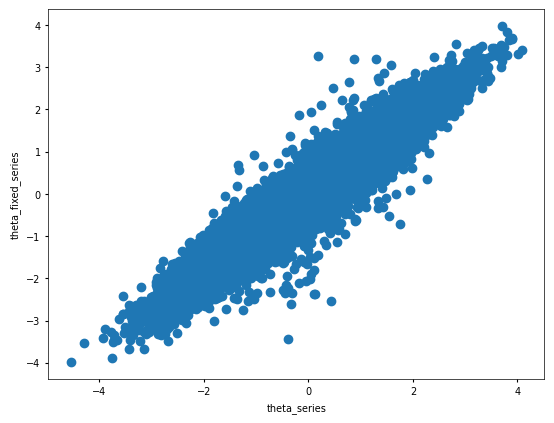

In [8]:
import matplotlib.pyplot as plt
plt.scatter(theta_series, theta_fixed_series)
plt.xlabel('theta_series')
plt.ylabel('theta_fixed_series')

In [ ]:
# Got the mavenn gauge fixing working for pairwise models. 
# Slowest step by far is translating theta_dict to theta_series. 
# Without this it seems pretty fast. 
# And I can probably speed this up by asigning values in the series with block asignments. 
# Actually yeah, I think this should speed things up a fair amount, maybe ~alpha**2 fold because that's how much the look ups will be reduced. 